In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
#Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

In [2]:
url_SocialMediaP = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv"

dt_SocialMediaP = pd.read_csv(url_SocialMediaP, sep= ",")

print("Primeras filas")
dt_SocialMediaP.head()

Primeras filas


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [3]:
dt_SocialMediaP.describe(include="all")

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


In [4]:
print("Dimensiones:", dt_SocialMediaP.shape)

print("\nInformación general")
dt_SocialMediaP.info()

print("\nTipos de datos")
print(dt_SocialMediaP.dtypes)

Dimensiones: (6000, 9)

Información general
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB

Tipos de datos
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              

In [5]:
print("Valores nulos por columna")
print(dt_SocialMediaP.isnull().sum())

print("\nDuplicados:", dt_SocialMediaP.duplicated().sum())

Valores nulos por columna
age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

Duplicados: 0


In [6]:
#Eliminando nulls del dataset.

# Rellenar con la media Valores numericos(float)
dt_SocialMediaP = dt_SocialMediaP.fillna(dt_SocialMediaP.mean(numeric_only=True))

#Rellenar con la moda el addition_level(str)
dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].fillna(
    dt_SocialMediaP["addiction_level"].mode()[0]
)

print("\nNulos después:")
print(dt_SocialMediaP.isnull().sum())

print("\nTamaño final:")
print(dt_SocialMediaP.shape)


Nulos después:
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

Tamaño final:
(6000, 9)


In [7]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

# CAMBIO AQUÍ: Usamos una lista para incluir "object" y "str" explícitamente
for col in dt_SocialMediaP.select_dtypes(include=["object", "str"]).columns:
    if col == "addiction_level":
        dt_SocialMediaP[col] = dt_SocialMediaP[col].map(jerarquia)
    else:
        dt_SocialMediaP[col] = le.fit_transform(dt_SocialMediaP[col])

dt_SocialMediaP.info()
#Valores del addiction_level
dt_SocialMediaP['addiction_level'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   float64
 1   daily_screen_time      6000 non-null   float64
 2   social_media_hours     6000 non-null   float64
 3   study_hours            6000 non-null   float64
 4   sleep_hours            6000 non-null   float64
 5   notifications_per_day  6000 non-null   float64
 6   focus_score            6000 non-null   float64
 7   addiction_level        6000 non-null   int64  
 8   productivity_score     6000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


array([1, 0, 2], dtype=int64)

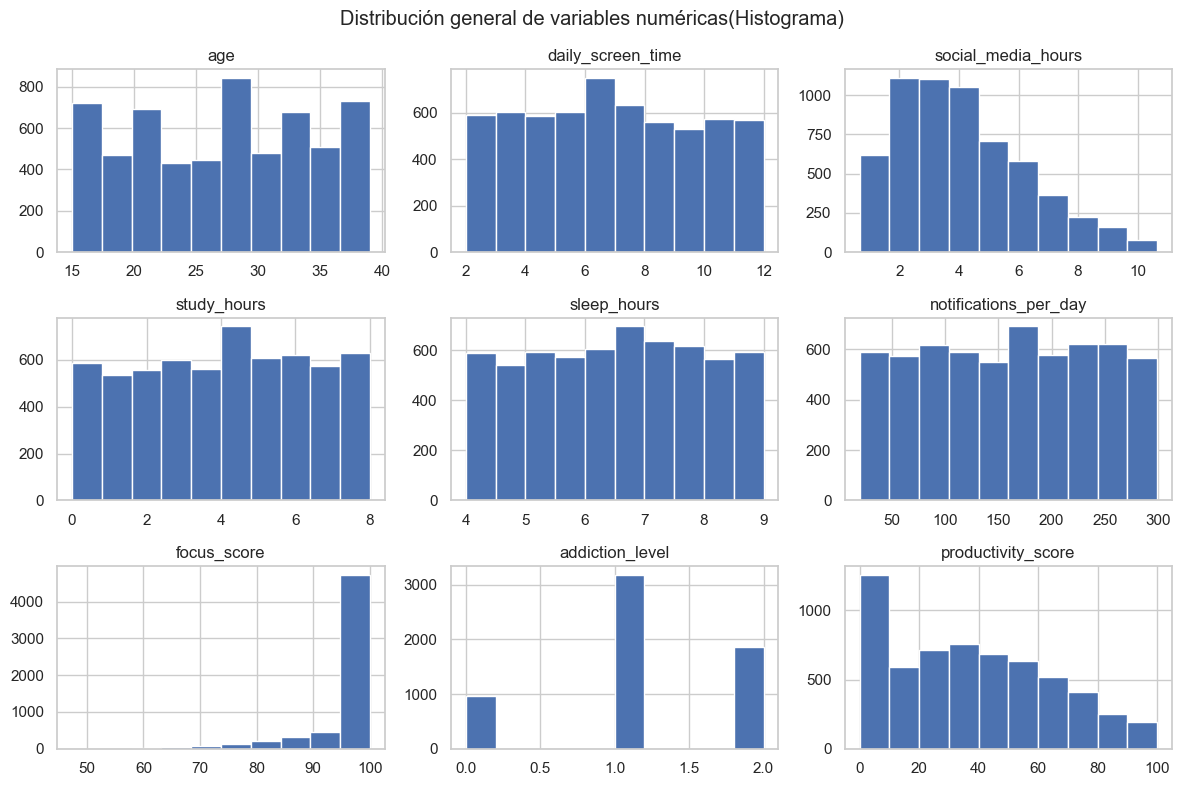

In [8]:
#Histograma
dt_SocialMediaP.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

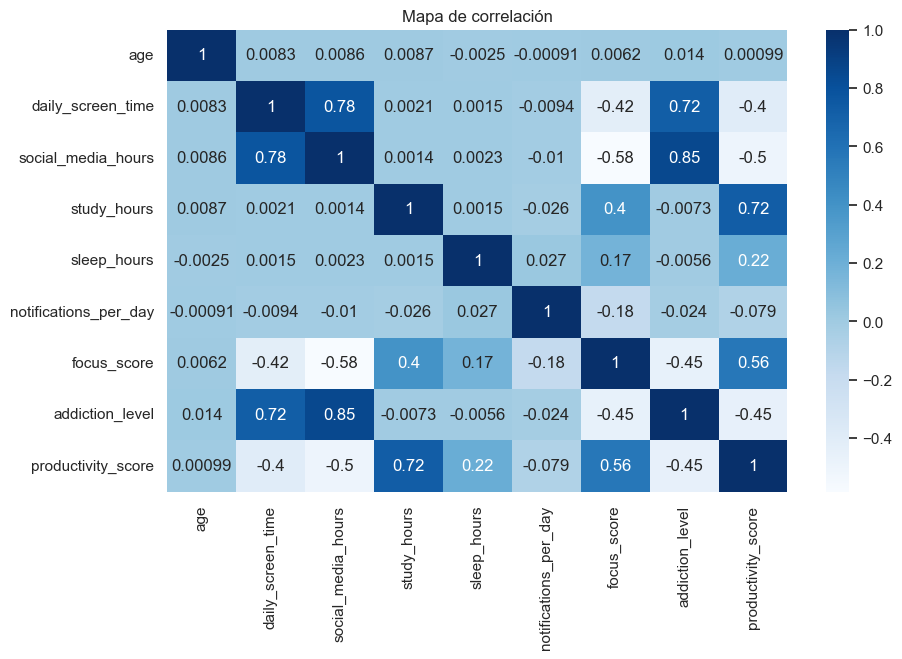

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dt_SocialMediaP.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de correlación")
plt.show()

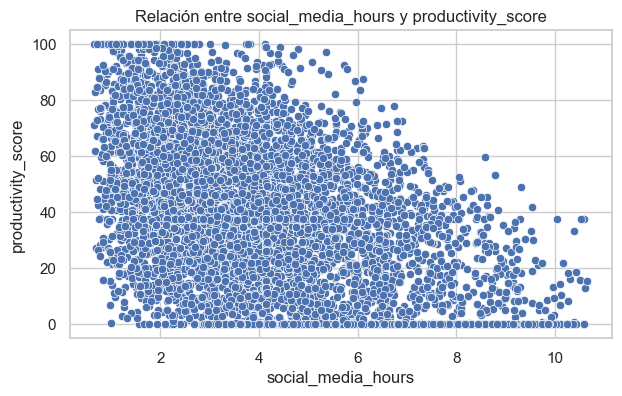

In [10]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=dt_SocialMediaP,
    x="social_media_hours",
    y="productivity_score"
)

plt.title("Relación entre social_media_hours y productivity_score")
plt.show()

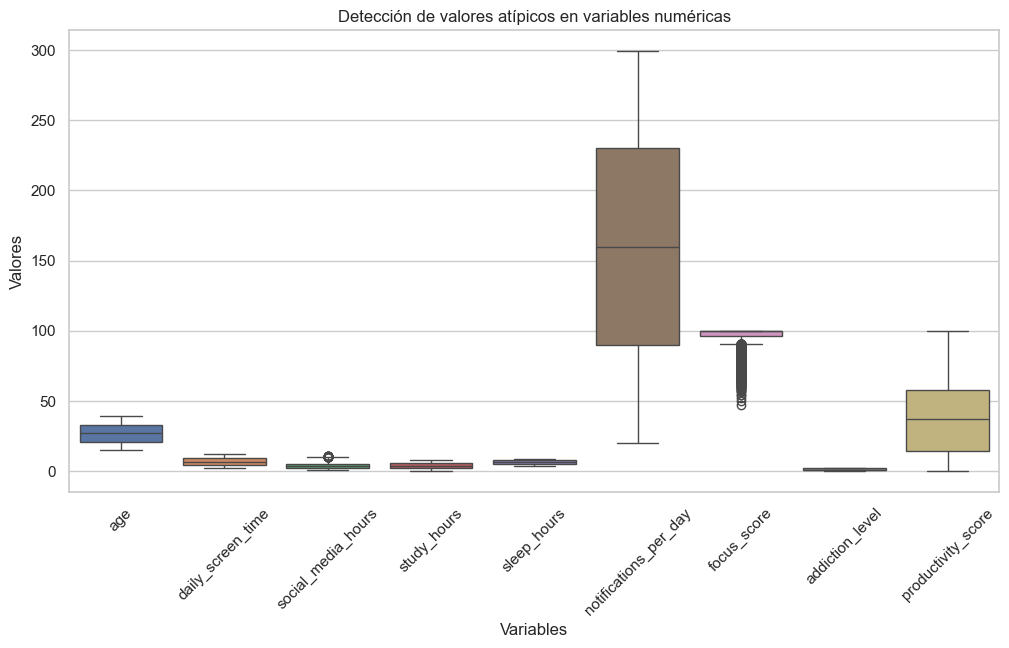

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dt_SocialMediaP.select_dtypes(include="number"))

plt.xticks(rotation=45)
plt.title("Detección de valores atípicos en variables numéricas")
plt.xlabel("Variables")
plt.ylabel("Valores")

plt.show()

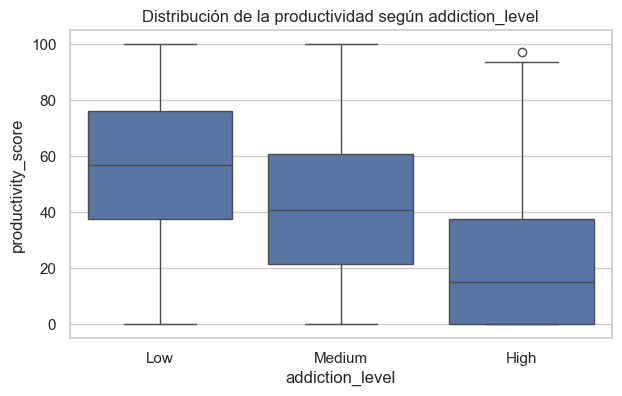

In [12]:
mapa_adiccion = {0: "Low", 1: "Medium", 2: "High"}

dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].map(mapa_adiccion)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=dt_SocialMediaP,
    x="addiction_level",
    y="productivity_score",
    order=["Low", "Medium", "High"]
)

plt.title("Distribución de la productividad según addiction_level")
plt.show()

## Hallazgos EDA


Durante el análisis exploratorio preliminar se logran observar 2 variables objetivo **productivity_score** y **addiction_level** siendo estas las de mayor relevancia para el conjunto de datos analizado. De igual manera se observó que las variables numéricas presentan distribuciones relativamente estables, con una mayor concentración de registros en rangos medios de *productivity_score* y *focus_score*, lo que sugiere un comportamiento general consistente en los niveles de productividad y enfoque de los usuarios.

El mapa de correlación evidenció una relación negativa entre *social_media_hours* y *productivity_score*, indicando que, a medida que aumentan las horas dedicadas a redes sociales, la productividad tiende a disminuir. De manera complementaria, la variable *sleep_hours* mostró una asociación positiva con *focus_score*, sugiriendo que mayores horas de descanso se relacionan con mejores niveles de concentración.

Finalmente, el gráfico de distribución de la productividad según *addiction_level* permitió identificar que los usuarios con un nivel de adicción alto (High) presentan medianas de productividad más bajas, reforzando la hipótesis de que un mayor grado de dependencia al uso de redes sociales impacta negativamente en el desempeño de las actividades diarias.

# Modelo de Redes Neuronales para Clasificación de Nivel de Adicción

En esta sección, implementaremos un modelo de red neuronal para clasificar el nivel de adicción a las redes sociales (addiction_level) utilizando los datos del dataset de Social Media Productivity. Basándonos en el EDA realizado previamente, utilizaremos las características numéricas escaladas.

El modelo consistirá en:
- Una capa de entrada
- Dos capas ocultas (intermedias) con funciones de activación ReLU y dropout
- Una capa de salida con activación softmax para clasificación multiclase

Utilizaremos TensorFlow/Keras para construir y entrenar el modelo.

### Reglas del ejercicio para modelo básico
- El dataset escogido ha de contar, como mínimo, con **1000 instancias** y el grupo deberá trabajar con todas ellas. Se deberá consensuar qué fracción se emplea para entrenar los modelos y la fracción que se usa para el test de los mismos, **siempre que se haga uso en total de al menos 1000 instancias** en todos los modelos.
    - Distribución: 80 training, 20 testing
- El problema de clasificación a resolver contará con, al menos, una *variable categórica* de **al menos 5 clases posibles a la salida**, y que dependa de, **al menos, 6 variables/atributos de entrada**.

El Dataset cumple la mayoría de las reglas con excepción del número de clases a la salida.
- *addiction_level* tiene tres clases (Low, Medium, High).
- Una propuesta es convertir el valor de *productivity_score* a cinco categorías.
    - Los valores de la variable van del 0 al 100, se convierten en 5 categorías de productividad.

**Rango** | **Clase** |
----------|------------
0-20      |  Muy baja |
21-40     |  Baja     |
41-60     |  Media    |
61-80     |  Alta     |
81-100    |  Muy Alta |

### Métodos de Clasificación no basados en Redes Neuronales
**Propuesta.**
- Predicción de la Productividad

**Variable objetivo**
- productivity_level

**Variables influyentes**
 #  | **Variable**       | **Correlación** | **Interpretación**                      |
 -- |--------------------|-----------------|-----------------------------------------|
 1  | study_hours        | 0.72            | estudiar aumenta productividad          |
 2  | focus_score        | 0.56            | mayor concentración mejora resultados   |
 3  | sleep_hours        | 0.22            | dormir mejor ayuda ligeramente          |
 4  | daily_screen_time  | -0.4            | exceso de pantalla reduce productividad |
 5  | social_media_hours | -0.5            | redes sociales afectan desempeño        |
 6  | addiction_level    | -0.45           | adicción digital reduce productividad   |


**Planteamiento del problema**
- ¿Cómo predecir la productividad de una persona a partir de sus hábitos digitales y de estudio?

El factor más determinante del sistema es:
- social_media_hours - El exceso de redes sociales reduce la productividad.

porque afecta directamente:
- adicción
- concentración
- productividad

Por lo tanto, cualquier estrategia de mejora del desempeño debe controlar el uso de redes sociales.

In [ ]:
# Crear una copia del DataFrame para análisis posterior
dt_SocialMediaP_Class = dt_SocialMediaP.copy()

### Conversión de *productivity_score* a cinco categorías, creación de *productivity_level*

In [ ]:
bins = [0,20,40,60,80,100]
labels = ['Muy baja','Baja','Media','Alta','Muy alta']

dt_SocialMediaP_Class['productivity_level'] = pd.cut(
    dt_SocialMediaP_Class['productivity_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dt_SocialMediaP_Class[['productivity_score','productivity_level']].head()

,productivity_score,productivity_level
0,28.49,Baja
1,18.54,Muy baja
2,68.52,Alta
3,27.82,Baja
4,51.09,Media


### Distribución de Clases

In [ ]:
dt_SocialMediaP_Class['productivity_level'].value_counts()

productivity_level
Muy baja    1843
Baja        1466
Media       1315
Alta         931
Muy alta     445
Name: count, dtype: int64

## Preparar variables de entrada y salida

In [ ]:
#Eliminamos la variable objetivo y la variable original de productividad para crear el conjunto de características (X) y la variable objetivo (y).
Xcl = dt_SocialMediaP_Class.drop(columns=['productivity_level','productivity_score'])
ycl = dt_SocialMediaP_Class['productivity_level']

## Codificar variables categóricas

In [ ]:
encoder = LabelEncoder()
Xcl['addiction_level'] = encoder.fit_transform(Xcl['addiction_level'])

## División entrenamiento y prueba

In [ ]:
Xcl_train, Xcl_test, ycl_train, ycl_test = train_test_split(
    Xcl,
    ycl,
    test_size=0.2,
    random_state=42,
    stratify=ycl
)

print(f"Conjunto de entrenamiento: {Xcl_train.shape}")
print(f"Conjunto de prueba: {Xcl_test.shape}")
print(f"Características utilizadas: {Xcl.columns.tolist()}")

Conjunto de entrenamiento: (4800, 8)
Conjunto de prueba: (1200, 8)
Características utilizadas: ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'addiction_level']


## Balanceo con SMOTE + Undersampling

In [ ]:
smote = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('under', under)
])

X_resampled, y_resampled = pipeline.fit_resample(Xcl_train, ycl_train)

pd.Series(y_resampled).value_counts()

productivity_level
Muy baja    1474
Baja        1474
Media       1474
Alta        1474
Muy alta    1474
Name: count, dtype: int64

# Modelo de Redes Neuronales para Clasificación

En esta sección, crearemos un modelo de redes neuronales para clasificar el nivel de productividad ('productivity_level') utilizando el conjunto de datos balanceado con SMOTE. El modelo incluirá al menos dos capas intermedias, como se requiere en el ejercicio.

## Pasos del proceso:
1. **Importación de librerías necesarias**: Importaremos TensorFlow/Keras para construir la red neuronal.
2. **Preparación de datos**: Escalaremos las características y codificaremos la variable objetivo en formato one-hot.
3. **Construcción del modelo**: Crearemos un modelo secuencial con capas densas.
4. **Entrenamiento del modelo**: Entrenaremos el modelo con los datos balanceados.
5. **Evaluación**: Evaluaremos el rendimiento en el conjunto de prueba.

In [ ]:
# Importación de librerías para redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Preparación de datos para el modelo de redes neuronales

# Escalamos las características
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Codificamos la variable objetivo en one-hot
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_resampled)
y_onehot = to_categorical(y_encoded)

# Dividimos en entrenamiento y validación (usando el conjunto resampleado)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_resampled_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Forma del conjunto de entrenamiento: {X_train_nn.shape}")
print(f"Forma del conjunto de validación: {X_val_nn.shape}")
print(f"Número de clases: {y_onehot.shape[1]}")

In [ ]:
# Construcción del modelo de redes neuronales

model = Sequential()

# Capa de entrada
model.add(Dense(64, input_dim=X_train_nn.shape[1], activation='relu'))

# Primera capa intermedia
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))  # Regularización

# Segunda capa intermedia
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(y_onehot.shape[1], activation='softmax'))

# Compilación del modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Resumen del modelo
model.summary()

In [ ]:
# Entrenamiento del modelo

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_nn, y_val_nn),
    verbose=1
)

In [ ]:
# Evaluación del modelo en el conjunto de prueba

# Preparamos el conjunto de prueba
X_test_scaled = scaler.transform(Xcl_test)
y_test_encoded = label_encoder.transform(ycl_test)
y_test_onehot = to_categorical(y_test_encoded)

# Evaluamos el modelo
loss, accuracy = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"Pérdida en el conjunto de prueba: {loss:.4f}")
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

# Predicciones
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_onehot, axis=1)

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test_labels, y_pred, target_names=label_encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Red Neuronal')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## Explicación del Modelo de Redes Neuronales

### Arquitectura del Modelo:
- **Capa de entrada**: 64 neuronas con activación ReLU, correspondiente al número de características escaladas.
- **Primera capa intermedia**: 32 neuronas con ReLU y Dropout (0.2) para evitar sobreajuste.
- **Segunda capa intermedia**: 16 neuronas con ReLU y Dropout (0.2).
- **Capa de salida**: 5 neuronas (una por clase) con activación Softmax para clasificación multiclase.

### Preparación de Datos:
- Las características fueron escaladas usando `StandardScaler` para normalizar los datos.
- La variable objetivo categórica ('productivity_level') fue codificada en one-hot para el entrenamiento.
- Se utilizó el conjunto balanceado con SMOTE para abordar el desbalance de clases.

### Entrenamiento:
- Optimizador: Adam
- Función de pérdida: Categorical Crossentropy (adecuada para clasificación multiclase)
- Métricas: Accuracy
- Épocas: 50
- Batch size: 32
- Validación: 20% del conjunto de entrenamiento balanceado

### Evaluación:
- El modelo se evaluó en el conjunto de prueba original (no balanceado) para medir el rendimiento real.
- Se generó un reporte de clasificación con precisión, recall y F1-score por clase.
- La matriz de confusión visualiza las predicciones correctas e incorrectas.

Este modelo cumple con los requisitos del ejercicio al incluir al menos dos capas intermedias y utilizar SMOTE para balancear las clases antes del entrenamiento.